**Mengambil data dari Kaggle**

In [29]:
!pip install kaggle

In [30]:
kaggle = '/content/kaggle.json'

In [31]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [32]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [33]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = 'dataset'
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
    zip.extractall(extract_folder)
    print('Done')

Done


In [46]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [34]:
len(data_0)

2236

**Import Library**

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

**Membaca Dataset Gambar**

In [36]:
dataset_path = "/content/dataset"
image_size = (28, 28)

X = []
y = []

AUTO_INVERT = True

for label in range(10):
    folder_path = os.path.join(dataset_path, str(label))
    for file in os.listdir(folder_path):

        if not file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            continue

        img_path = os.path.join(folder_path, file)

        img = load_img(img_path, color_mode="grayscale", target_size=image_size)
        img_array = img_to_array(img).astype("float32")

        img_array = img_array / 255.0

        if AUTO_INVERT and img_array.mean() > 0.5:
            img_array = 1.0 - img_array

        X.append(img_array)
        y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X min/max/mean:", X.min(), X.max(), X.mean())

X shape: (21555, 28, 28, 1)
y shape: (21555,)
X min/max/mean: 0.0 1.0 0.050949883


**Preprocessing MLP**

In [37]:
X = X.reshape(X.shape[0], 28 * 28)
print("After flatten:", X.shape)

After flatten: (21555, 784)


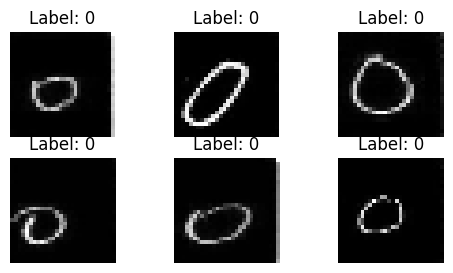

In [38]:
plt.figure(figsize=(6,3))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(X[i].reshape(28,28), cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.show()

**Split Data Train & Test**

In [39]:
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Encoding**

In [40]:
y_train = to_categorical(y_train_raw, num_classes=10)
y_test  = to_categorical(y_test_raw,  num_classes=10)

print("y_train:", y_train.shape, "y_test:", y_test.shape)

y_train: (17244, 10) y_test: (4311, 10)


**Making Model MLP**

In [41]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Latih Model**

In [42]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3310 - loss: 2.0085 - val_accuracy: 0.5467 - val_loss: 1.4200
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6032 - loss: 1.2983 - val_accuracy: 0.6377 - val_loss: 1.1438
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7088 - loss: 0.9806 - val_accuracy: 0.7229 - val_loss: 0.9047
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7879 - loss: 0.7266 - val_accuracy: 0.7786 - val_loss: 0.7437
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8506 - loss: 0.5472 - val_accuracy: 0.8012 - val_loss: 0.6421
Epoch 6/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8827 - loss: 0.4306 - val_accuracy: 0.8307 - val_loss: 0.5633
Epoch 7/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9155 - loss: 0.3285 - val_accuracy: 0.8423 - val_loss: 0.5319
Epoch 8/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9296 - loss: 0.2715 - val_accuracy: 0

**Evaluasi Model**

In [43]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss      :", test_loss)
print("Test Accuracy  :", test_acc)

Test Loss      : 0.570957601070404
Test Accuracy  : 0.8575736284255981


**Confusion Matrix dan Classification Report**

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       447
           1       0.88      0.93      0.90       448
           2       0.93      0.87      0.90       447
           3       0.85      0.84      0.84       441
           4       0.83      0.85      0.84       436
           5       0.86      0.83      0.85       425
           6       0.87      0.84      0.86       424
           7       0.88      0.89      0.89       423
           8       0.82      0.75      0.78       417
           9       0.74      0.84      0.79       403

    accuracy                           0.86      4311
   macro avg       0.86      0.86      0.86      4311
weighted avg       0.86      0.86      0.86      4311



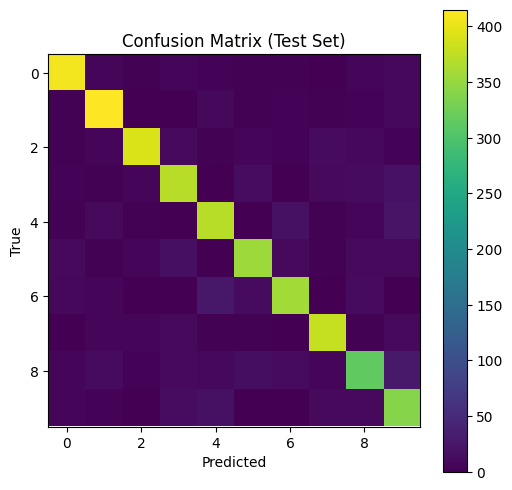

In [44]:
y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_test_raw, y_pred))

cm = confusion_matrix(y_test_raw, y_pred)
plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

**Visualisasi**

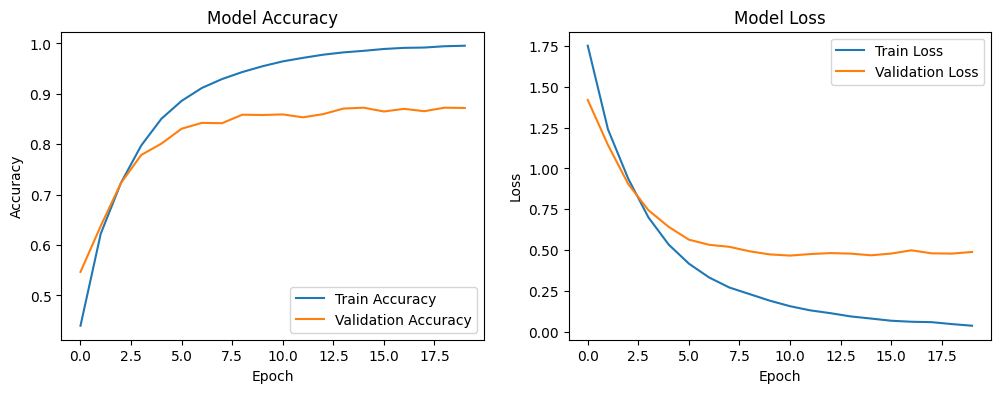

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()